In [1]:
# Importamos Pandas y NumPy para manejar datos numéricos.
import pandas as pd
import numpy as np

# Importamos Matplotlib para crear gráficas analíticas.
import matplotlib.pyplot as plt

# Importamos funciones para muestreo, escalado y división de datos.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Importamos la regresión logística como modelo base probabilístico.
from sklearn.linear_model import LogisticRegression

# Importamos las métricas supervisadas.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
ruta = "us_congestion_2016_2022_sample_2m.csv"
df_completo = pd.read_csv(ruta)

columnas_X = ['Start_Lng', 'Start_Lat', 'DelayFromTypicalTraffic(mins)', 'Temperature(F)']
columna_y = 'Severity'

# Limpieza y filtro de seguridad
df_metrics = df_completo[columnas_X + [columna_y]].dropna()
conteo_clases = df_metrics[columna_y].value_counts()
df_metrics = df_metrics[df_metrics[columna_y].isin(conteo_clases[conteo_clases >= 5].index)]

# Extraemos 100,000 observaciones estratificadas
df_muestra = resample(df_metrics, n_samples=100000, random_state=42, stratify=df_metrics[columna_y])

X_raw = df_muestra[columnas_X]
y = df_muestra[columna_y].values
clases_nombres = [f"Clase {c}" for c in sorted(df_muestra[columna_y].unique())]

# Estandarizamos los datos
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases detectadas:", clases_nombres)

Shape de X: (100000, 4)
Shape de y: (100000,)
Clases detectadas: ['Clase 0', 'Clase 1', 'Clase 2', 'Clase 3']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                  
    y,                  
    test_size=0.2,      # 20,000 registros para prueba
    random_state=42,    
    stratify=y          
)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)

Shape de X_train: (80000, 4)
Shape de X_test: (20000, 4)


In [6]:
# Creamos el modelo de regresión logística
# (En versiones modernas de scikit-learn, detecta automáticamente que es multiclase)
model = LogisticRegression(
    max_iter=1000,      
    random_state=42
)

# Entrenamos el modelo
model.fit(X_train, y_train)

# Predecimos la CLASE final
y_pred = model.predict(X_test)

# Predecimos las PROBABILIDADES de pertenecer a cada una de las 4 clases
y_prob = model.predict_proba(X_test)

print("Modelo base entrenado y predicciones generadas correctamente.")

Modelo base entrenado y predicciones generadas correctamente.


In [7]:
# Calculamos métricas globales ponderadas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.5102
Precision: 0.5235
Recall:    0.5102
F1-score:  0.4437


In [8]:
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=clases_nombres, zero_division=0)

print("Matriz de confusión pura:")
print(cm)
print("\nReporte de clasificación detallado:")
print(report)

Matriz de confusión pura:
[[ 492 4365    5    0]
 [ 330 8119  881   10]
 [  97 3564 1528   47]
 [   1  137  359   65]]

Reporte de clasificación detallado:
              precision    recall  f1-score   support

     Clase 0       0.53      0.10      0.17      4862
     Clase 1       0.50      0.87      0.64      9340
     Clase 2       0.55      0.29      0.38      5236
     Clase 3       0.53      0.12      0.19       562

    accuracy                           0.51     20000
   macro avg       0.53      0.34      0.34     20000
weighted avg       0.52      0.51      0.44     20000



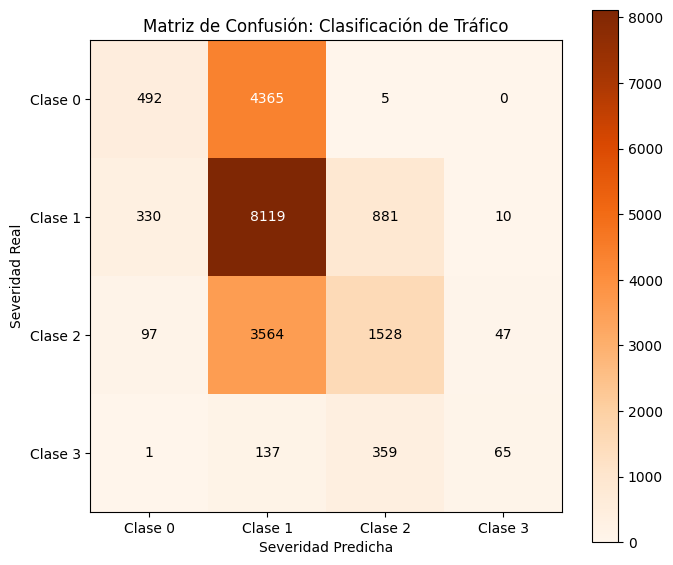

In [9]:
_, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Oranges") # Usamos colores cálidos para el tráfico
plt.colorbar(im)

ax.set_xticks(np.arange(len(clases_nombres)))
ax.set_yticks(np.arange(len(clases_nombres)))
ax.set_xticklabels(clases_nombres)
ax.set_yticklabels(clases_nombres)

ax.set_xlabel("Severidad Predicha")
ax.set_ylabel("Severidad Real")
ax.set_title("Matriz de Confusión: Clasificación de Tráfico")

# Anotamos los números en las celdas
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

AUC-ROC Global (Multiclase): 0.7106


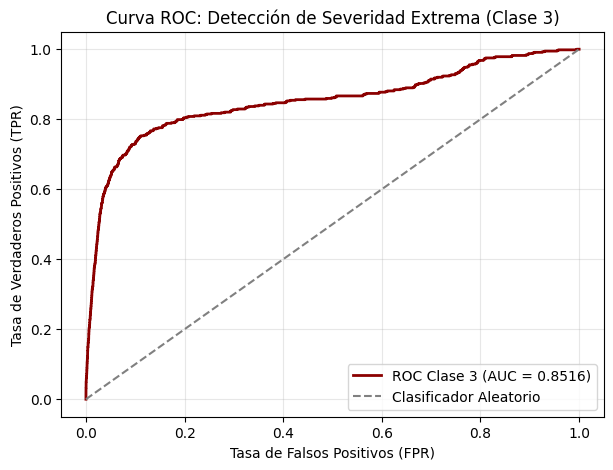

In [10]:
# 1. Calculamos el AUC global (Estrategia One-vs-Rest)
auc_global = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"AUC-ROC Global (Multiclase): {auc_global:.4f}")

# 2. Preparamos datos binarios solo para la Clase 3 (Extrema)
y_test_clase3 = (y_test == 3).astype(int)
y_prob_clase3 = y_prob[:, 3] # Columna de probabilidad de la clase 3

# Calculamos los puntos de la curva ROC para la Clase 3
fpr, tpr, thresholds = roc_curve(y_test_clase3, y_prob_clase3)
auc_clase3 = roc_auc_score(y_test_clase3, y_prob_clase3)

# Dibujamos
_, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkred', lw=2, label=f"ROC Clase 3 (AUC = {auc_clase3:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador Aleatorio")

ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curva ROC: Detección de Severidad Extrema (Clase 3)")
ax.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [11]:
metricas = {
    "Accuracy Ponderado": acc,
    "Precision Ponderada": prec,
    "Recall Ponderado": rec,
    "F1-score Ponderado": f1,
    "AUC-ROC Global": auc_global,
    "AUC-ROC (Solo Clase 3)": auc_clase3
}

print("--- RESUMEN DE AUDITORÍA DEL MODELO ---")
for nombre, valor in metricas.items():
    print(f"{nombre:<25}: {valor:.4f}")

--- RESUMEN DE AUDITORÍA DEL MODELO ---
Accuracy Ponderado       : 0.5102
Precision Ponderada      : 0.5235
Recall Ponderado         : 0.5102
F1-score Ponderado       : 0.4437
AUC-ROC Global           : 0.7106
AUC-ROC (Solo Clase 3)   : 0.8516


In [12]:
# Tomamos el registro número 50 del conjunto de pruebas
nuevo_caso_escalado = X_test[50].reshape(1, -1)
nuevo_caso_real = scaler.inverse_transform(nuevo_caso_escalado)[0]

pred_nuevo = model.predict(nuevo_caso_escalado)[0]
prob_nuevo = model.predict_proba(nuevo_caso_escalado)[0]

print("Nuevo evento clínico/vial evaluado (Lng, Lat, Retraso, Temp):")
print(np.round(nuevo_caso_real, 2))
print(f"\nSeveridad Predicha Final: {clases_nombres[pred_nuevo]}")

print("\nNivel de certeza por clase:")
for i, prob in enumerate(prob_nuevo):
    print(f"  {clases_nombres[i]}: {prob*100:.2f}%")

Nuevo evento clínico/vial evaluado (Lng, Lat, Retraso, Temp):
[-82.63  28.52   0.    86.  ]

Severidad Predicha Final: Clase 1

Nivel de certeza por clase:
  Clase 0: 39.37%
  Clase 1: 49.66%
  Clase 2: 10.56%
  Clase 3: 0.41%
